# Import Libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
df = sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.shape

(150, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [20]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [44]:
df.describe(include='O')

/tmp/ipykernel_20439/2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,species
count,150
unique,3
top,setosa
freq,50


In [8]:
numerical = df.select_dtypes(include=[np.number])

In [10]:
numerical.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


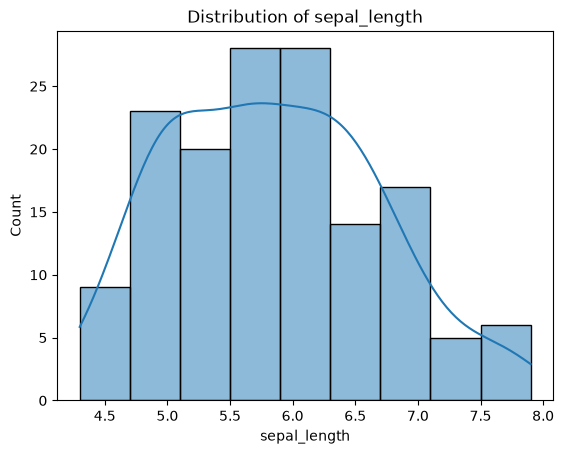

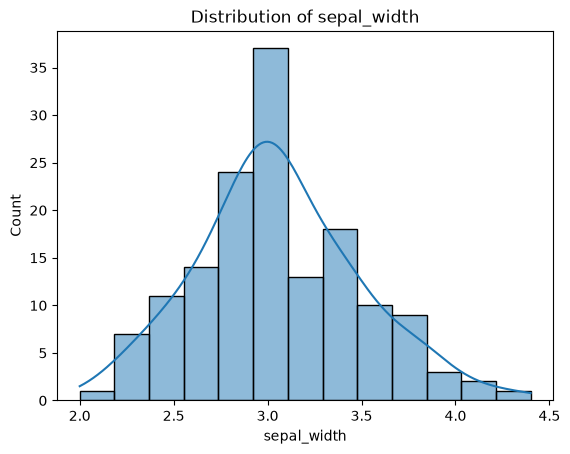

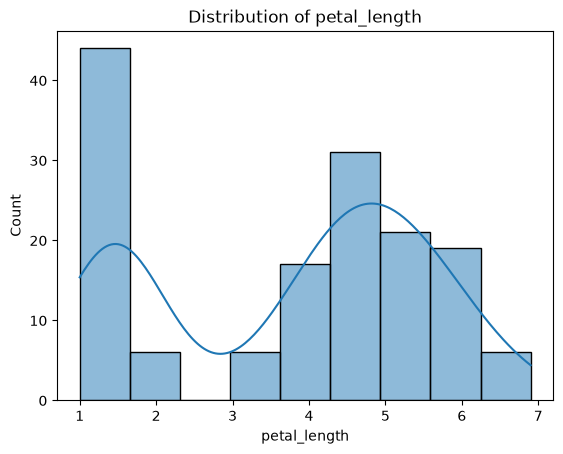

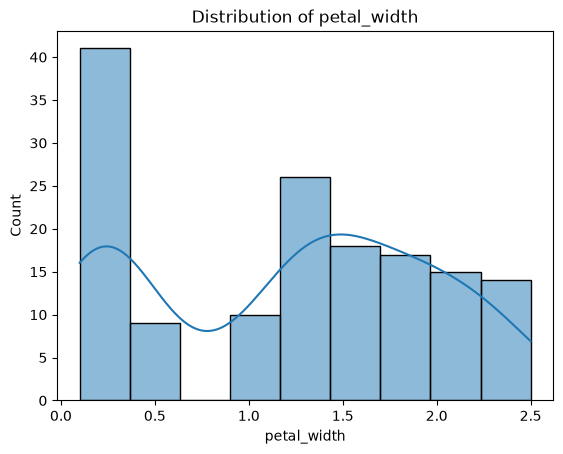

In [15]:
for col in numerical:
    sns.histplot(
        numerical[col],   
        kde=True   
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Count")

    plt.show()

In [19]:
df.groupby('species').agg(count=('species','count')).reset_index()

,species,count
0,setosa,50
1,versicolor,50
2,virginica,50


<Axes: xlabel='count', ylabel='species'>

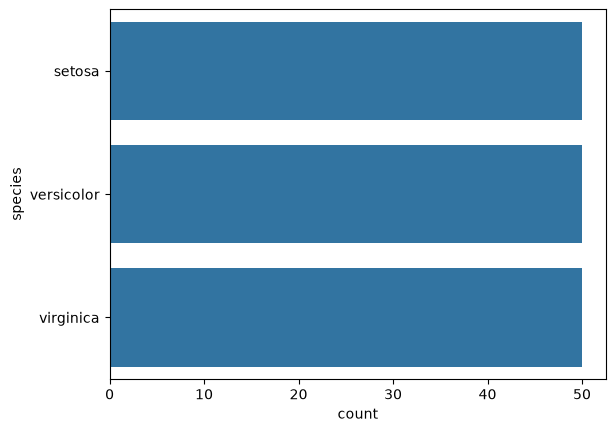

In [16]:
sns.countplot(df['species'])

In [86]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import mean_absolute_error as mae\
    , root_mean_squared_error as rmse\
    , r2_score, f1_score, confusion_matrix, ConfusionMatrixDisplay 


In [46]:
encoder = LabelEncoder()

In [47]:
X = df.drop('species',axis=1)
Y = df['species']

In [48]:
X.shape, Y.shape

((150, 4), (150,))

In [49]:
x_train , x_test , y_train , y_test = train_test_split(X,
                                                        Y,
                                                        test_size=0.2,
                                                        random_state=42)

In [50]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [51]:
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [52]:
y_train_encoded[:5]

array([0, 0, 1, 0, 0])

In [ ]:
model_linear = LinearRegression()

model_linear.fit(x_train,y_train_encoded)

y_pred = model_linear.predict(x_test)


In [56]:
y_pred[:10]

array([ 1.23071715, -0.04010441,  2.21970287,  1.34966889,  1.28429336,
        0.02248402,  1.05726124,  1.82403704,  1.36824643,  1.06766437])

In [58]:
model_svc = SVC()

model_svc.fit(x_train,y_train_encoded)

y_pred = model_svc.predict(x_test)

In [59]:
y_pred[:5]

array([1, 0, 2, 1, 1])

In [71]:
def evaluate(y_test,y_pred):
    print(f"MAE: {mae(y_test_encoded,y_pred)}")

    print(f"\nRMSE: {rmse(y_test_encoded,y_pred)}")

    print(f"\nR2-Score: {r2_score(y_test_encoded,y_pred)}")

    print(f"\n Confusion Matrix:\n{confusion_matrix(y_test_encoded,y_pred)}")


In [72]:
evaluate(y_test_encoded,y_pred)

MAE: 0.0

RMSE: 0.0

R2-Score: 1.0

 Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [73]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

def evaluate(y_test, y_pred):
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [74]:
evaluate(y_test_encoded,y_pred)

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [84]:
model_descisiontree = DecisionTreeClassifier()

model_descisiontree.fit(x_train,y_train)

y_pred = model_descisiontree.predict(x_test)

In [85]:
evaluate(y_test,y_pred)

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


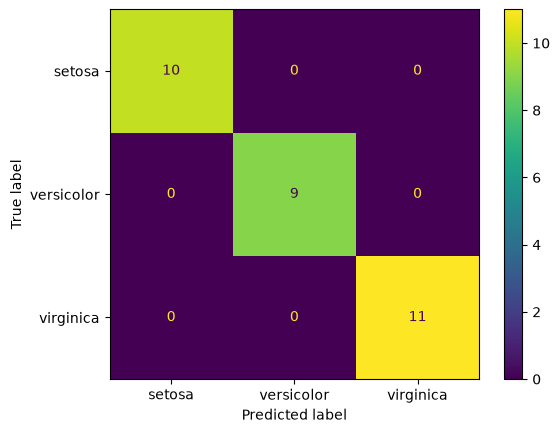

In [87]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
)

plt.show()